In [1]:
library(data.table)
library(tidyverse)
library(parallel)
library(Biostrings)

── Attaching core tidyverse packages ───────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ─────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks da

In [2]:
get_4fold_sites <- function(ref_seq) {
  codons <- substring(ref_seq, seq(1, nchar(ref_seq) - 2, by = 3), seq(3, nchar(ref_seq), by = 3))

  # Define all 4-fold degenerate codons
  codon_table_4fold <- c(
    "GCT","GCC","GCA","GCG",  # Ala
    "CGT","CGC","CGA","CGG",  # Arg
    "GGT","GGC","GGA","GGG",  # Gly
    "CCT","CCC","CCA","CCG",  # Pro
    "ACT","ACC","ACA","ACG",  # Thr
    "GTT","GTC","GTA","GTG",  # Val
    "TCT","TCC","TCA","TCG",  # Ser
    "CTT","CTC","CTA","CTG"   # Leu
  )

  is_4fold <- codons %in% codon_table_4fold
  third_base_indices <- which(is_4fold) * 3
  return(third_base_indices)
}


In [17]:
dnaFasta = readDNAStringSet("/workdir/sh2246/p_phyloGWAS/data/Zmays_cds.fa")
names(dnaFasta) = substr(names(dnaFasta),1,20)

In [18]:
dnaFasta

DNAStringSet object of length 39756:
        width seq                                           names               
    [1]  1842 ATGGCCGCCGCCGCCGCCACT...CAATCAAGCATAGGCAGTTAA Zm00001eb000010_T001
    [2]  1074 TTATTTTACCTCTGTAGTTCT...GTGGTGCAAAAACTTTGGTAA Zm00001eb000020_T004
    [3]   432 ATGCCATTTCATGAGGTCGTC...GCGATACCAGATTTTCTTTAG Zm00001eb000050_T001
    [4]   303 ATGGGGCTGAAGCGGCCTACG...CGGATGGAGCAGCGGGCCTAA Zm00001eb000060_T001
    [5]   774 ATGAAGAGAAAGGAAAACTCC...CCACTAGAGTCCGGAGAGTAG Zm00001eb000070_T001
    ...   ... ...
[39752]   231 ATGCTCGAGCTGCTCGCGCGG...CCGGCCGTGGTTCGGCCGTGA Zm00001eb436980_T001
[39753]   231 ATGCTCGAGCTGCTCGCGCGG...CCGGCCGTGGTTCGGCCGTGA Zm00001eb436990_T001
[39754]  1866 ATGATGGGAATAACTAAGCAG...GGCGCTGCTGGATACTTCTGA Zm00001eb437010_T001
[39755]  1527 ATGGAATTCTCACCAAGAGCT...GAAAGCGCTTTAAATTTATGA Zm00001eb437040_T001
[39756]   348 ATGGAACCTCTAGCCCGTCCT...TTGCGCCCACTTGGTGGATGA Zm00001eb437050_T001

In [76]:
dnaFasta = dnaFasta[sapply(dnaFasta,function(x) substr(as.character(x),1,3)=="ATG")]

In [77]:
tmp = letterFrequency(dnaFasta,letters = c("A","T","C","G"))
rownames(tmp) = names(dnaFasta)
gcPerGene = rowSums(tmp[,3:4])/rowSums(tmp)


In [78]:
dnaFasta4d = DNAStringSet(mclapply(dnaFasta,function(x) {
    Idx4d = get_4fold_sites(as.character(x))
    return(DNAString(paste(limma::strsplit2(as.character(x),"")[Idx4d],collapse = "")))
},mc.cores = 30))

In [79]:
dnaFasta4d

DNAStringSet object of length 38708:
        width seq                                           names               
    [1]   297 CCCCCTCCTAGTACAAGCGTC...ACGGGATGAACTATAACTAAC Zm00001eb000010_T001
    [2]    51 ACCTGATATGAAGCACCGGTG...CGCTATAGGGCCGTATAAGAT Zm00001eb000050_T001
    [3]    64 GGGTGGAGGAAGCGCGCGGCC...ATGATTTACCATGGAAGGGGC Zm00001eb000060_T001
    [4]   139 CGGGGTCGCGCCGCGCCAGGG...AGAGAAATCCGCTCACGAACA Zm00001eb000070_T001
    [5]    85 AGTGTAATATCTCATTTCTCA...CGAGGATCGTAATGTCACGCT Zm00001eb000080_T001
    ...   ... ...
[38704]    62 CGCGGAGCCGGGGAGAGCCGG...TCGGACCCCGGGGTCGCGTGG Zm00001eb436980_T001
[38705]    62 CGCGGAGCCGGGGAGAGCCGG...TCGGACCCCGGGGTCGCGTGG Zm00001eb436990_T001
[38706]   325 ATATTGTTTATAAGTAATATT...CAATCGGCGCAGTGACTCTTA Zm00001eb437010_T001
[38707]   243 AATGCGTAGGTAGCATAGAAT...TTTCCAAATATTACTCTTTTT Zm00001eb437040_T001
[38708]    56 TACTTTTCCCGGGGGCGTGGT...AATATAGTCTATGGGCCATTA Zm00001eb437050_T001

In [80]:
tmp = letterFrequency(dnaFasta4d,letters = c("A","T","C","G"))
rownames(tmp) = names(dnaFasta4d)
gcPerGene4d = rowSums(tmp[,3:4])/rowSums(tmp)


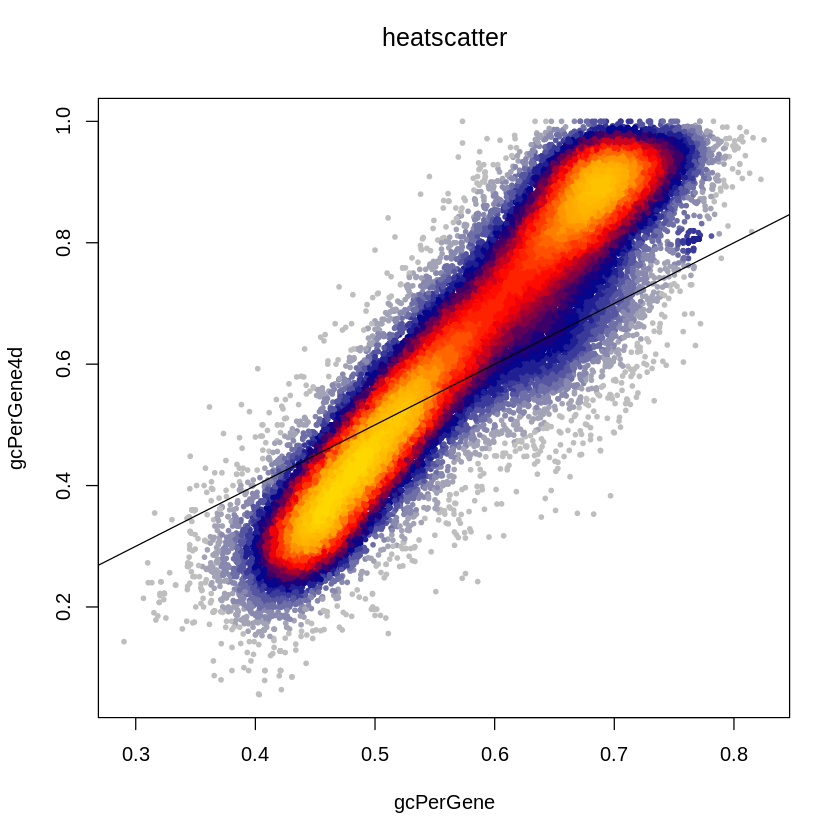

In [81]:
LSD::heatscatter(gcPerGene,gcPerGene4d)
abline(a =0,b=1)

In [82]:
dnaFasta4d50 = DNAStringSet(mclapply(dnaFasta,function(x) {
    Idx4d = get_4fold_sites(as.character(x))
    Idx4d2 = Idx4d[Idx4d<=150]
    if(length(Idx4d2)>5) return(DNAString(paste(limma::strsplit2(as.character(x),"")[Idx4d2],collapse = ""))) else return(NA)
},mc.cores = 30))

In [289]:
tmp = letterFrequency(dnaFasta4d50,letters = c("A","T","C","G"))
rownames(tmp) = names(dnaFasta4d50)
gcPerGene4d50 = rowSums(tmp[,3:4])/rowSums(tmp)


In [301]:
dnaFasta50 = DNAStringSet(mclapply(dnaFasta,function(x) {
    if(nchar(x)>=150) return(DNAString(paste(limma::strsplit2(as.character(x),"")[1:150],collapse = ""))) else return(x)
},mc.cores = 30))

In [302]:
head(dnaFasta50)

DNAStringSet object of length 6:
    width seq                                               names               
[1]   150 ATGGCCGCCGCCGCCGCCACTTT...TCCTCTTCCTCCTCCTGGGCCGC Zm00001eb000010_T001
[2]   150 ATGCCATTTCATGAGGTCGTCCA...CCAGGTGGGATATAATCGTCGTG Zm00001eb000050_T001
[3]   150 ATGGGGCTGAAGCGGCCTACGGC...CAACTCAAAGAAACGACGCCGCT Zm00001eb000060_T001
[4]   150 ATGAAGAGAAAGGAAAACTCCGC...CGTCGAAGCCGAGAACGCGGTCG Zm00001eb000070_T001
[5]   150 ATGAAGACAGGGATCGTTGAGAG...TTGGAATTGTAAATGGCATGGAT Zm00001eb000080_T001
[6]   150 ATGCTTCACTCCCAGTATGCCTC...CCGATGCCAAGCCAGAGGCTCCG Zm00001eb000100_T001

In [318]:
tmp = letterFrequency(dnaFasta50,letters = c("A","T","C","G"))
rownames(tmp) = names(dnaFasta50)
gcCompPerGene50 = tmp[,3:4]/rowSums(tmp)


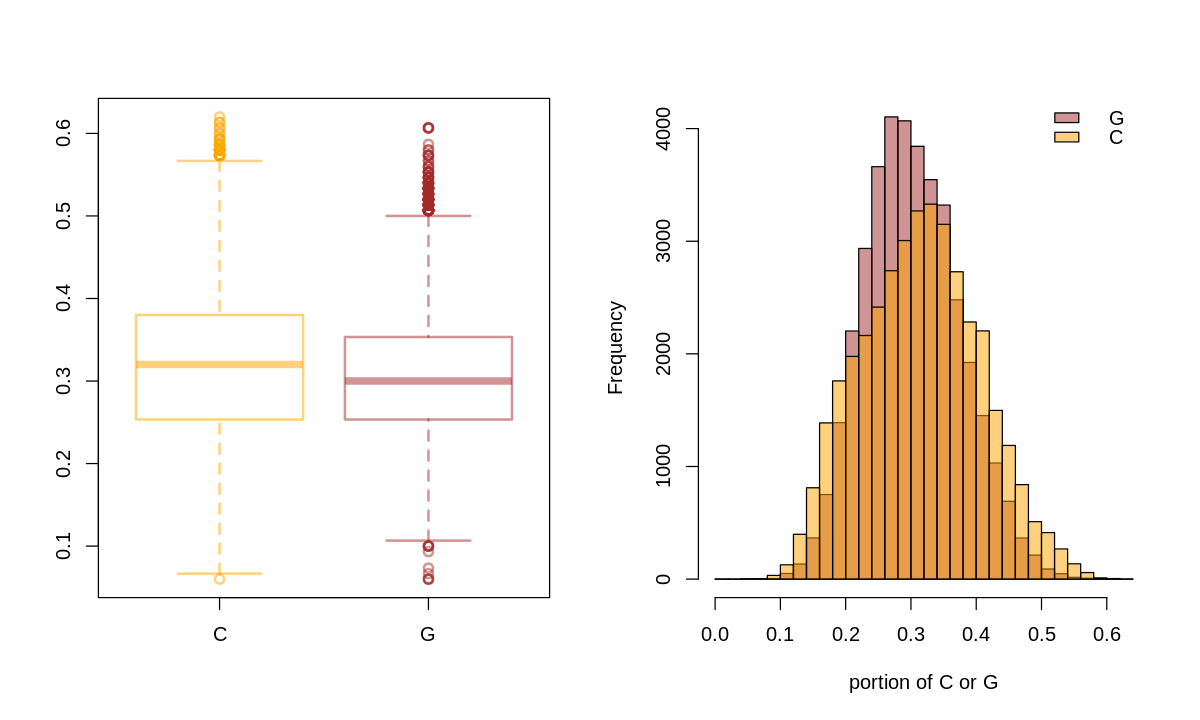

In [326]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
boxplot(gcCompPerGene50, border = alpha(c("orange","brown"),.5),col = NA,lwd = 2)
hist(gcCompPerGene50[,2],col = alpha("brown",.5),main = "",xlab = "portion of C or G",breaks = seq(0,0.65,0.02))
hist(gcCompPerGene50[,1],add = T, col = alpha("orange",.5),breaks = seq(0,0.65,0.02))
legend("topright",legend = c("G", "C"), fill = alpha(c("brown","orange"),.5),bty = 'n')

In [355]:
tmp = letterFrequency(dnaFasta,letters = c("A","T","C","G"))
rownames(tmp) = names(dnaFasta)
gcCompPerGene = tmp[,3:4]/rowSums(tmp)


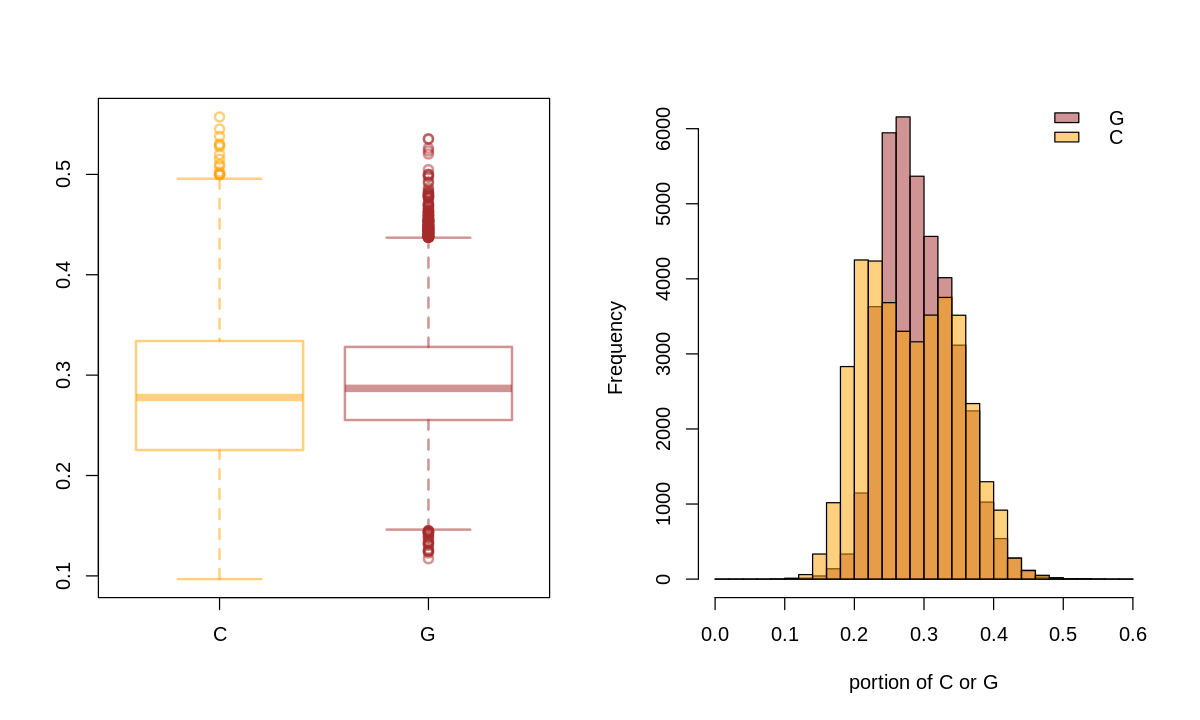

In [324]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
boxplot(gcCompPerGene, border = alpha(c("orange","brown"),.5),col = NA,lwd = 2)
hist(gcCompPerGene[,2],col = alpha("brown",.5),main = "",xlab = "portion of C or G",breaks = seq(0,0.6,0.02))
hist(gcCompPerGene[,1],add = T, col = alpha("orange",.5),breaks = seq(0,0.6,0.02))
legend("topright",legend = c("G", "C"), fill = alpha(c("brown","orange"),.5),bty = 'n')

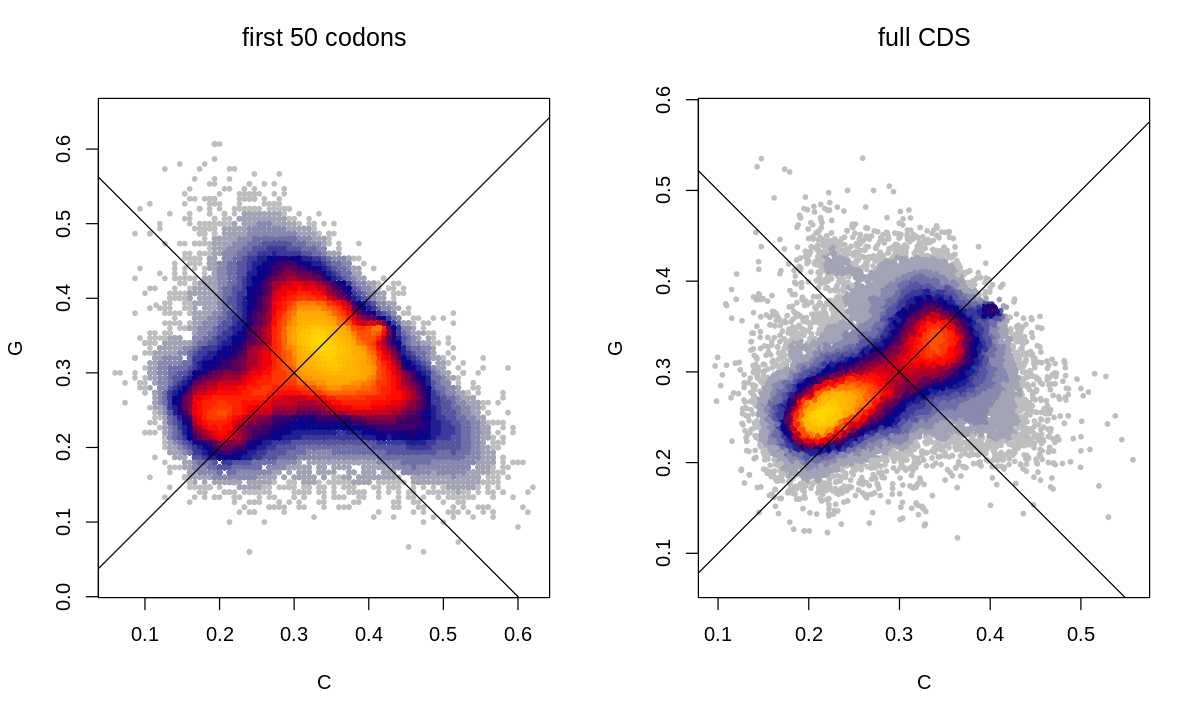

In [339]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
LSD::heatscatter(gcCompPerGene50[,1],gcCompPerGene50[,2],main = "first 50 codons",xlab = "C",ylab = "G",asp =1)
abline(a=.6,b= -1)
abline(a=0,b= 1)
LSD::heatscatter(gcCompPerGene[,1],gcCompPerGene[,2],main = "full CDS",xlab = "C",ylab = "G",asp = 1)
abline(a=.6,b= -1)
abline(a=0,b= 1)

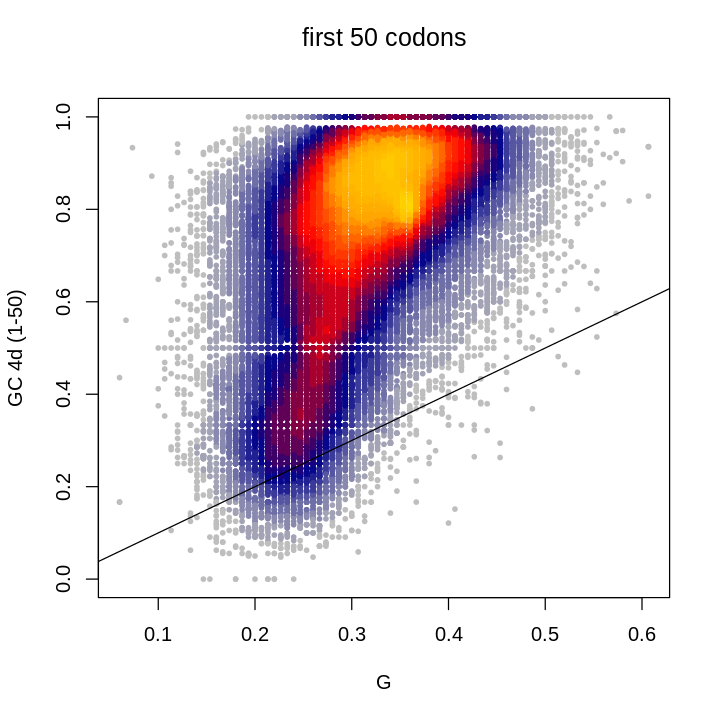

In [364]:
options(repr.plot.width=6, repr.plot.height=6)

LSD::heatscatter(gcCompPerGene50[,2],gcPerGene4d50,main = "first 50 codons",
                 xlab = "G",ylab = "GC 4d (1-50)")
abline(a=0,b= 1)


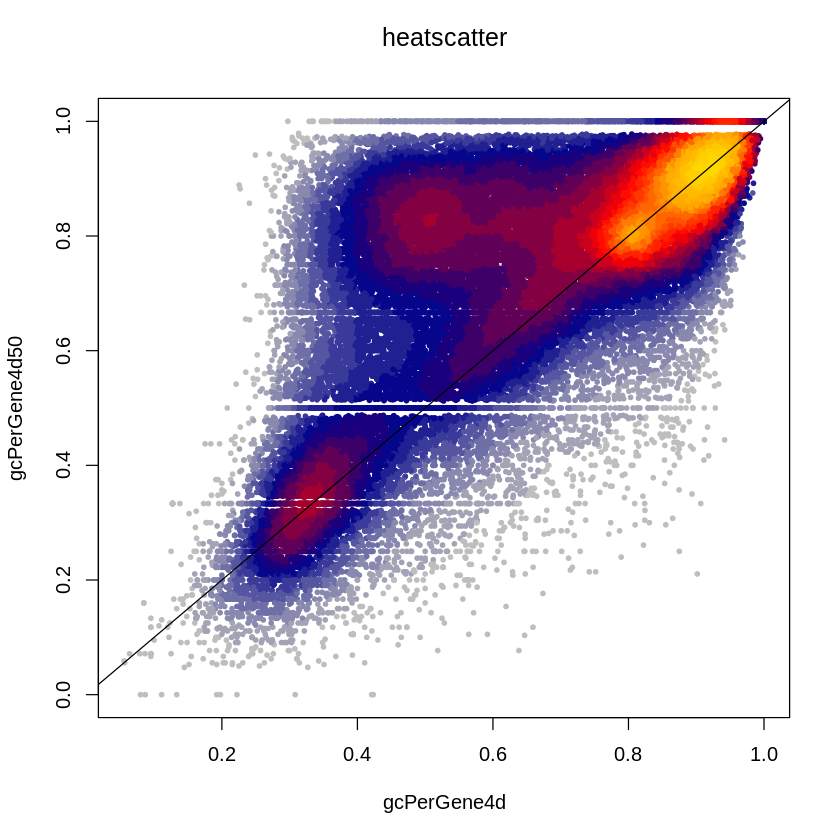

In [84]:
LSD::heatscatter(gcPerGene4d,gcPerGene4d50)
abline(a =0,b=1)

In [85]:
dnaFasta4d50up = mclapply(dnaFasta,function(x) {
    Idx4d = get_4fold_sites(as.character(x))
    Idx4d2 = Idx4d[Idx4d>150]
    if(length(Idx4d2)>5) return(DNAString(paste(limma::strsplit2(as.character(x),"")[Idx4d2],collapse = ""))) else return(NA)
},mc.cores = 30)
dnaFasta4d50up = DNAStringSet(dnaFasta4d50up[!is.na(dnaFasta4d50up)])

In [86]:
tmp = letterFrequency(dnaFasta4d50up,letters = c("A","T","C","G"))
rownames(tmp) = names(dnaFasta4d50up)
gcPerGene4d50up = rowSums(tmp[,3:4])/rowSums(tmp)


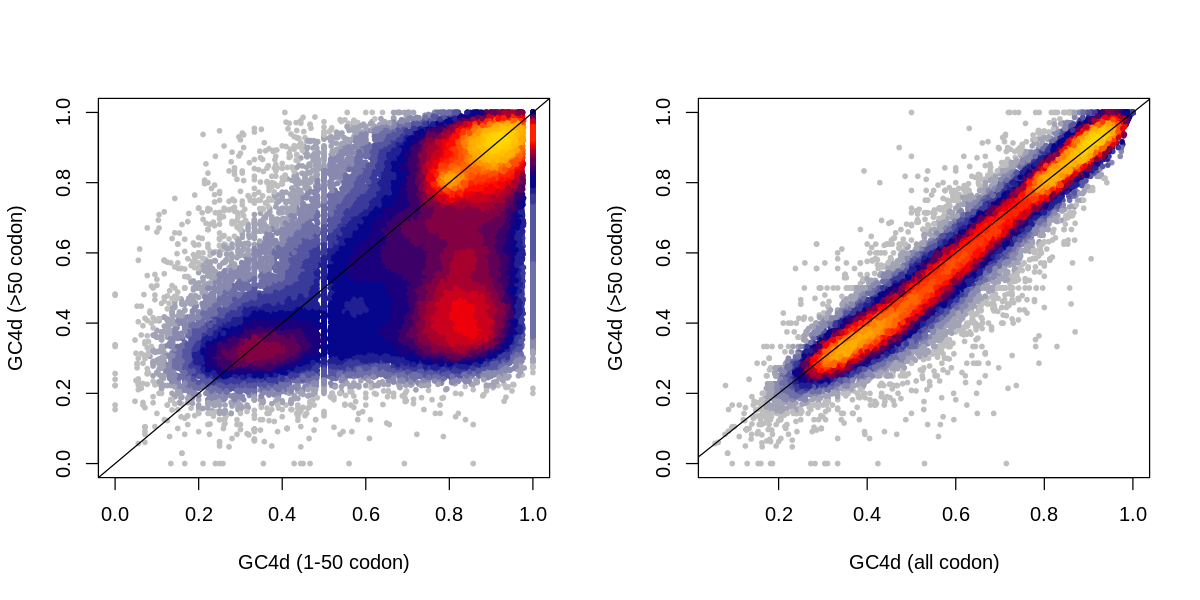

In [192]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow = c(1,2))
LSD::heatscatter(gcPerGene4d50[names(gcPerGene4d50up)],gcPerGene4d50up,
                 xlab = "GC4d (1-50 codon)",ylab = "GC4d (>50 codon)",main = "")
abline(a =0,b=1)

LSD::heatscatter(gcPerGene4d[names(gcPerGene4d50up)],gcPerGene4d50up,
                 xlab = "GC4d (all codon)",ylab = "GC4d (>50 codon)",main = "")
abline(a =0,b=1)

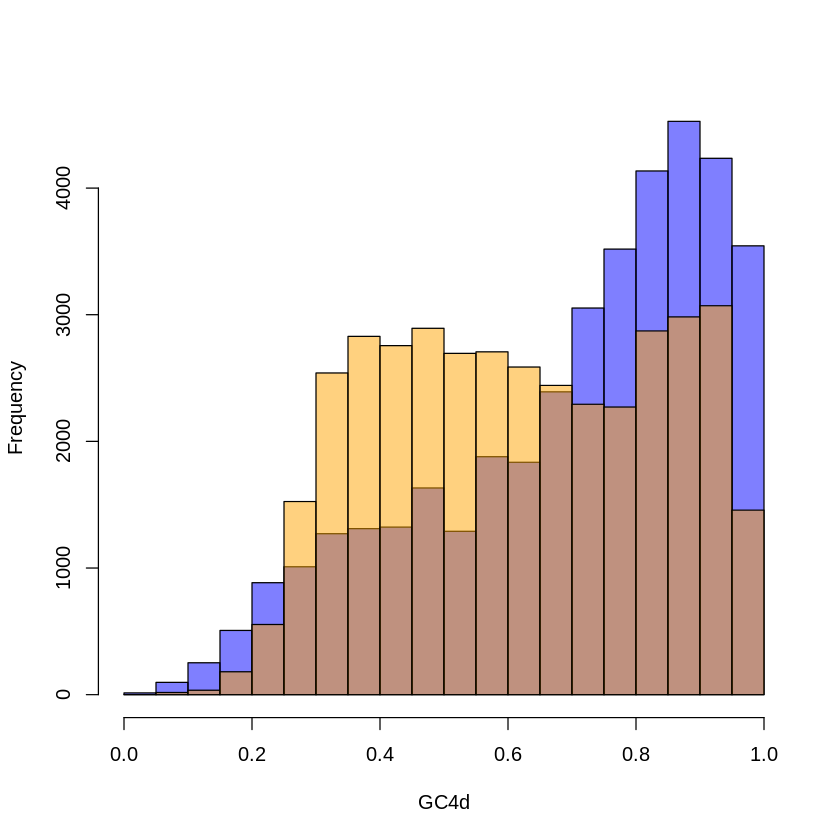

In [92]:
hist(gcPerGene4d50,breaks = seq(0,1,0.05),xlab = "GC4d",main="",col = scales::alpha("blue",.5))
hist(gcPerGene4d,breaks = seq(0,1,0.05),add = T,col = scales::alpha("orange",.5))

In [225]:
reelGene = read.delim("/workdir/sh2246/p_geneModelEvaluation/output/allTranscripts_summary_20230314.txt",header = T)

In [271]:
table(reelGene$Subgenome)


   M1    M2 
10843  6696 

In [226]:
reelGene = reelGene[reelGene$Canonical == 1,]

In [227]:
reelGene = reelGene[-which(duplicated(reelGene$GeneID)),]

In [228]:
rownames(reelGene) = reelGene$transcript

In [230]:
head(reelGene)

,transcript,GeneID,score,class,Subgenome,number_genome_presence,AED,Protein,Pseudogene,nCDS,reelProteinScore,Canonical,reelCDS,reelExon,trscStartJunctionScore,trscStopJunctionScore
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Zm00001eb000010_T001,Zm00001eb000010_T001,Zm00001eb000010,0.94871897,Near-Core Gene,NA,25,0.23,0,1,7,0.94981766,1,0.88946325,0.98339927,0.9073220,0.9729033
Zm00001eb000020_T001,Zm00001eb000020_T001,Zm00001eb000020,0.20982872,Core Gene,NA,26,0.21,1,1,9,0.01302490,1,0.04524887,0.00189044,0.1525586,0.4811094
Zm00001eb000050_T001,Zm00001eb000050_T001,Zm00001eb000050,0.02119545,Dispensable Gene,NA,20,0.63,0,1,6,0.06809892,1,0.01044356,0.00302929,0.3379473,NA
Zm00001eb000060_T001,Zm00001eb000060_T001,Zm00001eb000060,0.02841591,Dispensable Gene,NA,23,0.34,0,1,2,0.15611205,1,0.02958577,0.03178709,0.0203169,0.2120504
Zm00001eb000070_T001,Zm00001eb000070_T001,Zm00001eb000070,0.02472691,Dispensable Gene,NA,23,0.61,0,1,6,0.18377978,1,0.02670151,0.00223711,NA,NA
Zm00001eb000080_T001,Zm00001eb000080_T001,Zm00001eb000080,0.08083330,Near-Core Gene,NA,25,0.60,0,1,4,0.03443255,1,0.02721024,0.00108152,0.6785655,0.8403623


In [231]:
reelGeneNAM = read.csv("/workdir/sh2246/p_geneModelEvaluation/p_reelgene/reelGene_scores/reelGene_allNAM_publicationFinal.csv",header = T)

In [232]:
reelGeneNAM = reelGeneNAM[reelGeneNAM$taxaShort == "B73",]

In [235]:
reelGeneNAM = reelGeneNAM[!duplicated(reelGeneNAM$Gene),]

In [236]:
rownames(reelGeneNAM) = reelGeneNAM$Gene

In [244]:
mergedDat = cbind(reelGene[names(gcPerGene4d50),],gcPerGene4d50,maxConservation = reelGeneNAM[substr(names(gcPerGene4d50),1,15),]$maxConservation)

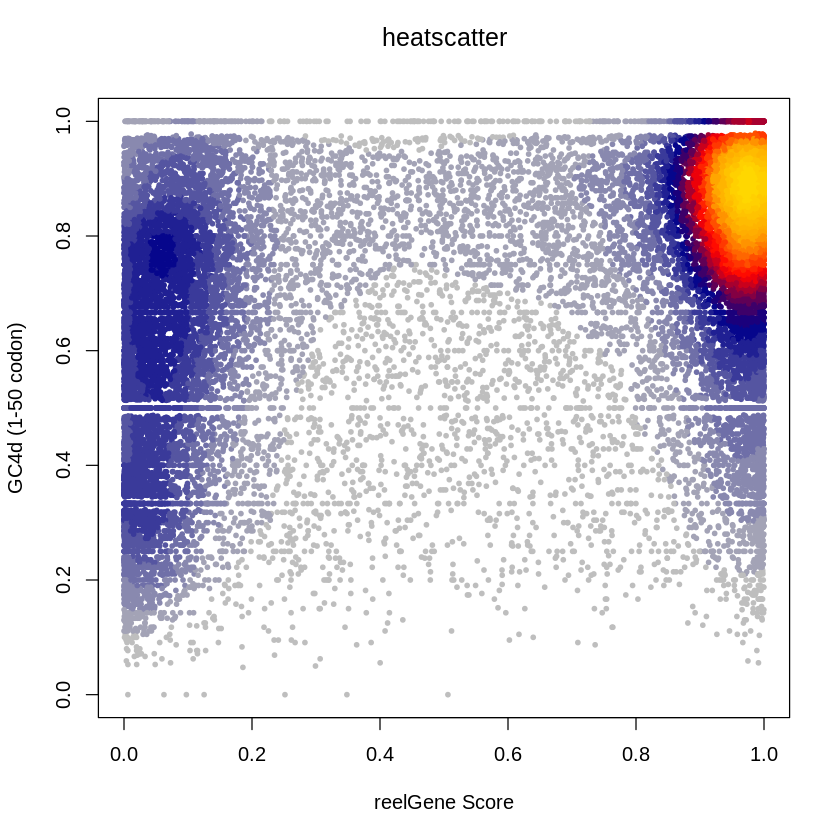

In [239]:
with(mergedDat,LSD::heatscatter(score,gcPerGene4d50,xlab = "reelGene Score",ylab = "GC4d (1-50 codon)"))

In [163]:
with(mergedDat,cor(score,gcPerGene4d50,method = "spearman",use = "complete"))

[1] 0.3910798

In [245]:
mergedDat$Subgenome[is.na(mergedDat$Subgenome)] = "not-assigned"

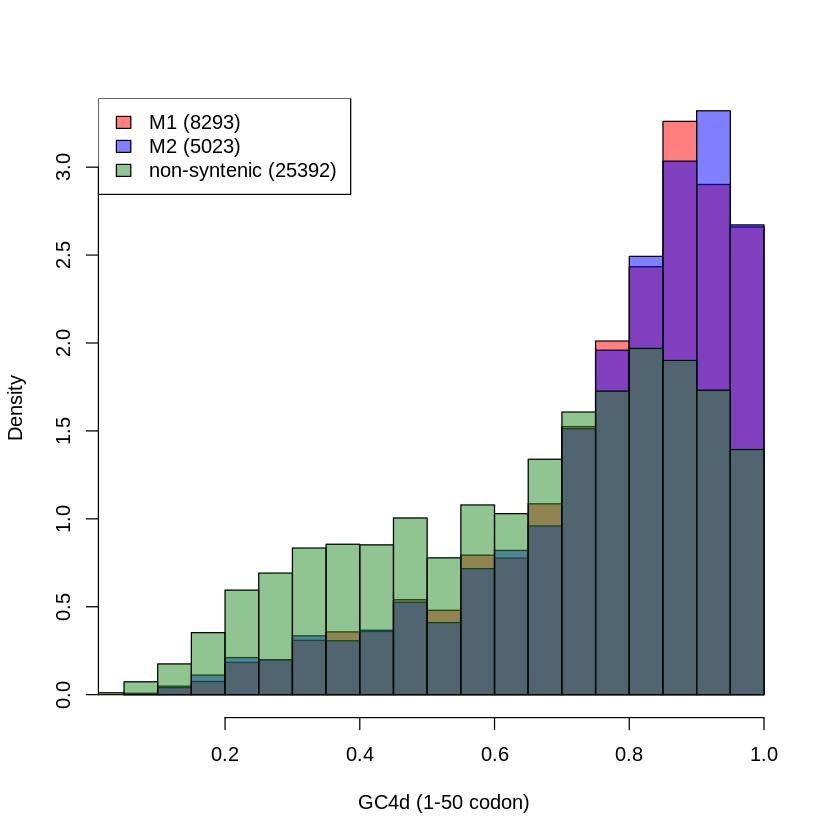

In [204]:
options(repr.plot.width=7, repr.plot.height=7)

with(mergedDat,hist(gcPerGene4d50[Subgenome == "M1"],xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("red",.5),freq = F))
with(mergedDat,hist(gcPerGene4d50[Subgenome == "M2"],col = alpha("blue",.5),add =T,freq = F))
with(mergedDat,hist(gcPerGene4d50[Subgenome == "not-assigned"],col = alpha("forestgreen",.5),add = T, freq = F))
legend("topleft",legend = c("M1 (8293)","M2 (5023)","non-syntenic (25392)"),fill = alpha(c("red","blue","forestgreen"),.5))

In [152]:
g4Gene = read.delim("/workdir/sh2246/p_phyloGWAS/output/G4quadruplexGene.gff3",header = F)

In [153]:
g4Gene = substr(g4Gene[,9],4,18)

In [246]:
mergedDat$G4 = as.numeric(mergedDat$GeneID%in%g4Gene)

In [201]:
with(mergedDat,table(G4))
with(mergedDat,table(Subgenome))

G4
    0     1 
29068  9640 

Subgenome
          M1           M2 not-assigned 
        8293         5023        25392 

In [161]:
t(with(mergedDat,table(G4,Subgenome)))/colSums(with(mergedDat,table(G4,Subgenome)))

              G4
Subgenome              0         1
  M1           0.6083444 0.3916556
  M2           0.6022297 0.3977703
  not-assigned 0.8269534 0.1730466

In [167]:
t(with(mergedDat[mergedDat$score>.5,],table(G4,Subgenome)))/colSums(with(mergedDat[mergedDat$score>.5,],table(G4,Subgenome)))

              G4
Subgenome              0         1
  M1           0.5918116 0.4081884
  M2           0.5856227 0.4143773
  not-assigned 0.6393983 0.3606017

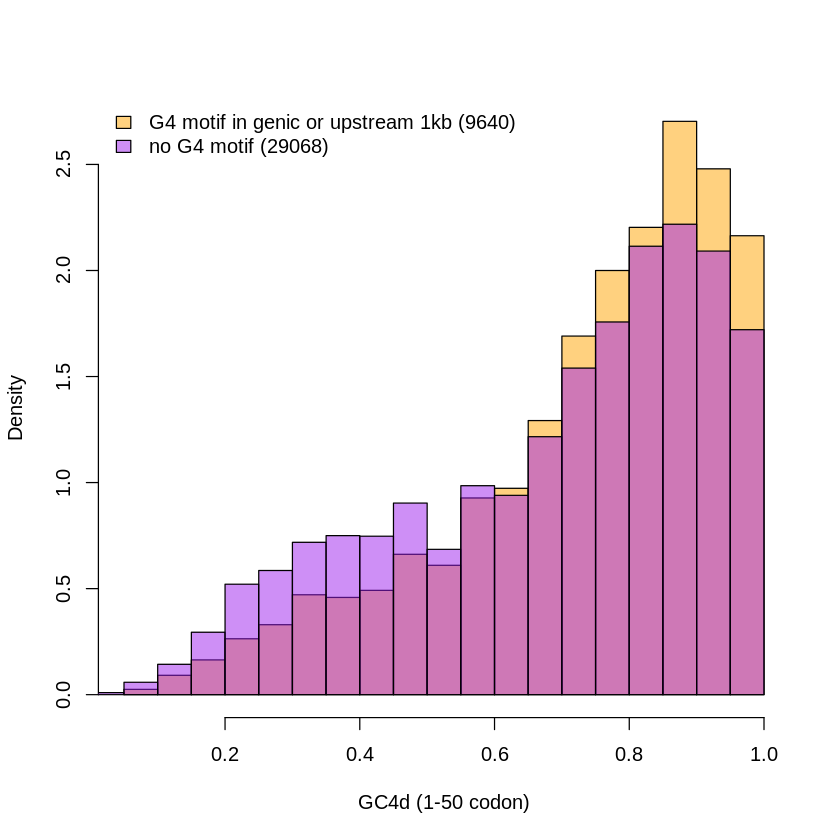

In [202]:
with(mergedDat,hist(gcPerGene4d50[G4 == 1],xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("orange",.5),freq = F))
with(mergedDat,hist(gcPerGene4d50[G4 == 0],col = alpha("purple",.5),add =T,freq = F))
legend("topleft",legend = c("G4 motif in genic or upstream 1kb (9640)","no G4 motif (29068)"),
       fill = alpha(c("orange","purple"),.5),bty = 'n')

In [174]:
zeaSpecGene = read.table("/workdir/sh2246/p_geneModelEvaluation/output/allzeaSpecGeneID.txt")[,1]

In [247]:
mergedDat$ZeaSpecific = as.numeric(mergedDat$transcript%in%zeaSpecGene)

In [198]:
table(mergedDat$ZeaSpecific)


    0     1 
38178   530 

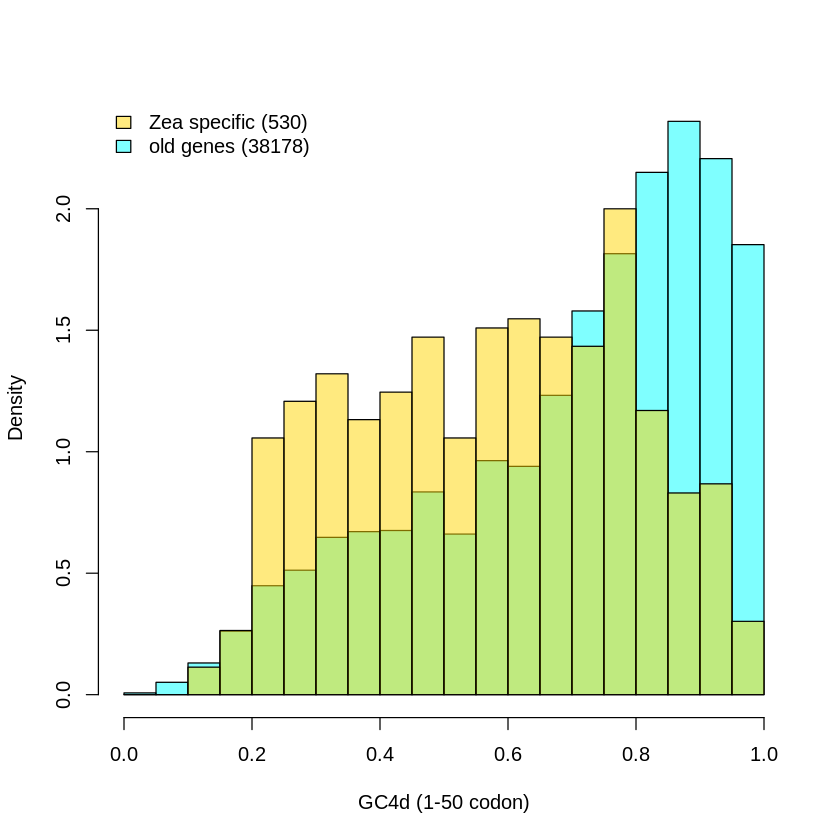

In [218]:
options(repr.plot.width=7, repr.plot.height=7)
with(mergedDat,hist(gcPerGene4d50[ZeaSpecific == 0],xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("cyan",.5),freq = F))
with(mergedDat,hist(gcPerGene4d50[ZeaSpecific == 1],col = alpha("gold",.5),add =T,freq = F,breaks = seq(0,1,0.05)))
legend("topleft",legend = c("Zea specific (530)","old genes (38178)"),
       fill = alpha(c("gold","cyan"),.5),bty = 'n')

In [249]:
table(mergedDat$maxConservation)


 Maize Specific     Outside Zea   Zea Conserved Zea Segregating 
            497           33924             591            2991 

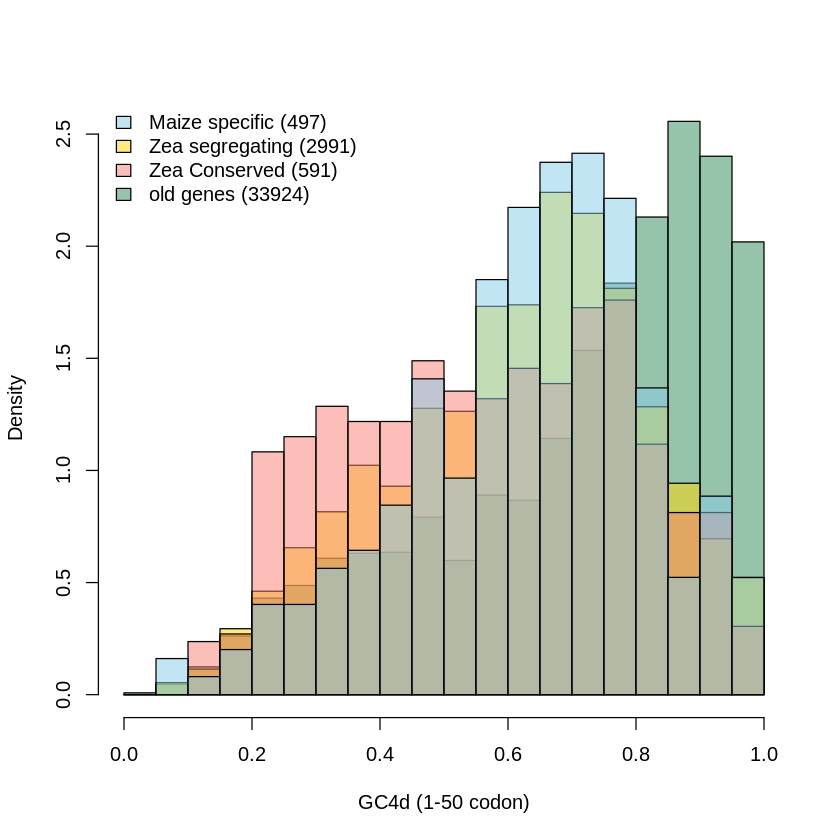

In [258]:
options(repr.plot.width=7, repr.plot.height=7)
with(mergedDat,hist(gcPerGene4d50[maxConservation == "Outside Zea"],xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("seagreen",.5),freq = F,breaks = seq(0,1,0.05)))
with(mergedDat,hist(gcPerGene4d50[maxConservation == "Zea Segregating"],col = alpha("gold",.5),add =T,freq = F,breaks = seq(0,1,0.05)))
with(mergedDat,hist(gcPerGene4d50[maxConservation == "Zea Conserved"],col = alpha("salmon",.5),add =T,freq = F,breaks = seq(0,1,0.05)))
with(mergedDat,hist(gcPerGene4d50[maxConservation == "Maize Specific"],col = alpha("skyblue",.5),add =T,freq = F,breaks = seq(0,1,0.05)))
legend("topleft",legend = c("Maize specific (497)","Zea segregating (2991)","Zea Conserved (591)","old genes (33924)"),
       fill = alpha(c("skyblue","gold","salmon","seagreen"),.5),bty = 'n')

In [267]:
2991+591

[1] 3582

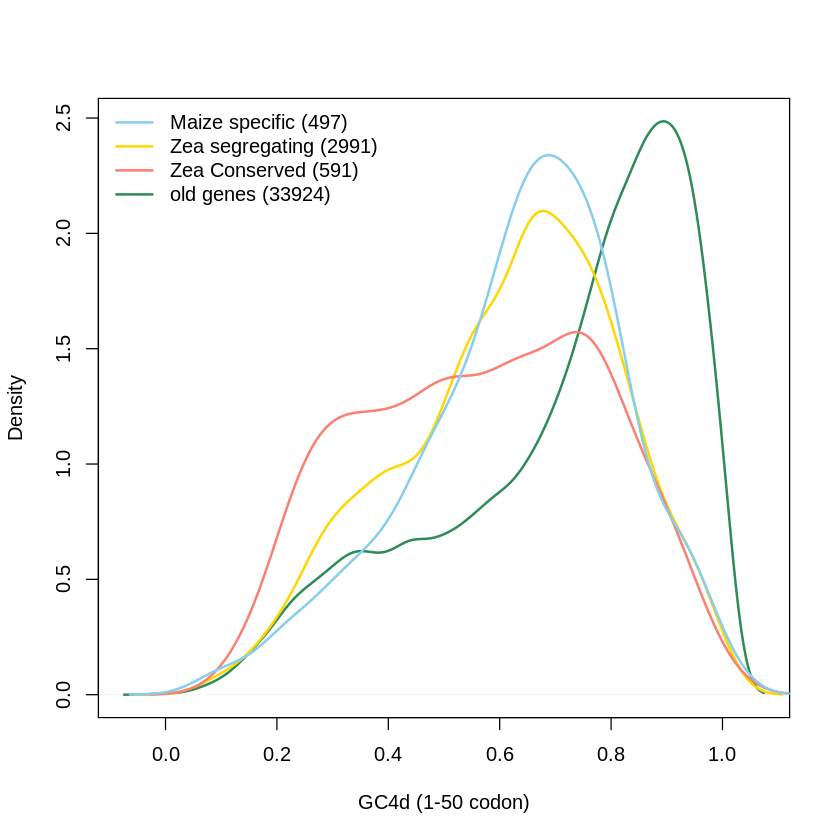

In [270]:
options(repr.plot.width=7, repr.plot.height=7)
with(mergedDat,plot(density(gcPerGene4d50[maxConservation == "Outside Zea"],na.rm = T),xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("seagreen",1),lwd =2))
with(mergedDat,lines(density(gcPerGene4d50[maxConservation == "Zea Segregating"],na.rm = T),
                     col = alpha("gold",1),lwd =2))
with(mergedDat,lines(density(gcPerGene4d50[maxConservation == "Zea Conserved"],na.rm = T),
                     col = alpha("salmon",1),lwd =2))
with(mergedDat,lines(density(gcPerGene4d50[maxConservation == "Maize Specific"],na.rm = T),
                     col = alpha("skyblue",1),lwd =2))
legend("topleft",legend = c("Maize specific (497)","Zea segregating (2991)","Zea Conserved (591)","old genes (33924)"),
       col = alpha(c("skyblue","gold","salmon","seagreen"),1),bty = 'n',lty =1, lwd = 2)

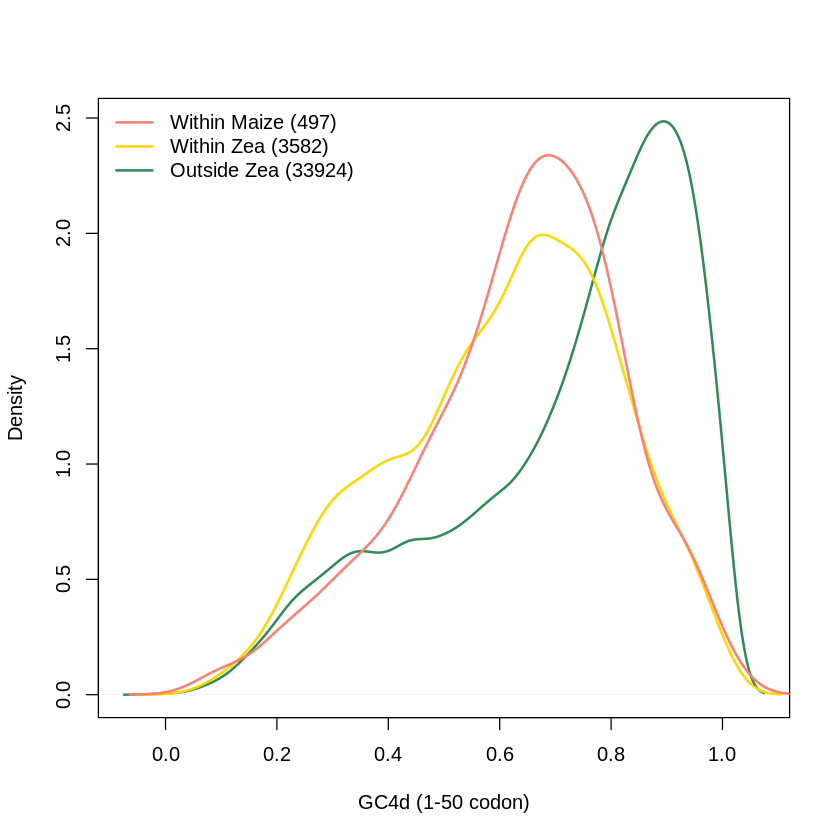

In [269]:
options(repr.plot.width=7, repr.plot.height=7)
with(mergedDat,plot(density(gcPerGene4d50[maxConservation == "Outside Zea"],na.rm = T),xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("seagreen",1),lwd =2))
with(mergedDat,lines(density(gcPerGene4d50[maxConservation %in% c("Zea Conserved","Zea Segregating")],na.rm = T),
                     col = alpha("gold",1),lwd =2))
with(mergedDat,lines(density(gcPerGene4d50[maxConservation == "Maize Specific"],na.rm = T),
                     col = alpha("salmon",1),lwd =2))
legend("topleft",legend = c("Within Maize (497)","Within Zea (3582)","Outside Zea (33924)"),
       col = alpha(c("salmon","gold","seagreen"),1),bty = 'n',lty =1, lwd = 2)

In [213]:
table(mergedDat[mergedDat$score>.5,]$Subgenome)
table(mergedDat[mergedDat$score>.5,]$G4)
table(mergedDat[mergedDat$score>.5,]$ZeaSpecific)


          M1           M2 not-assigned 
        7303         4368         4853 


   0    1 
9983 6541 


    0     1 
16512    12 

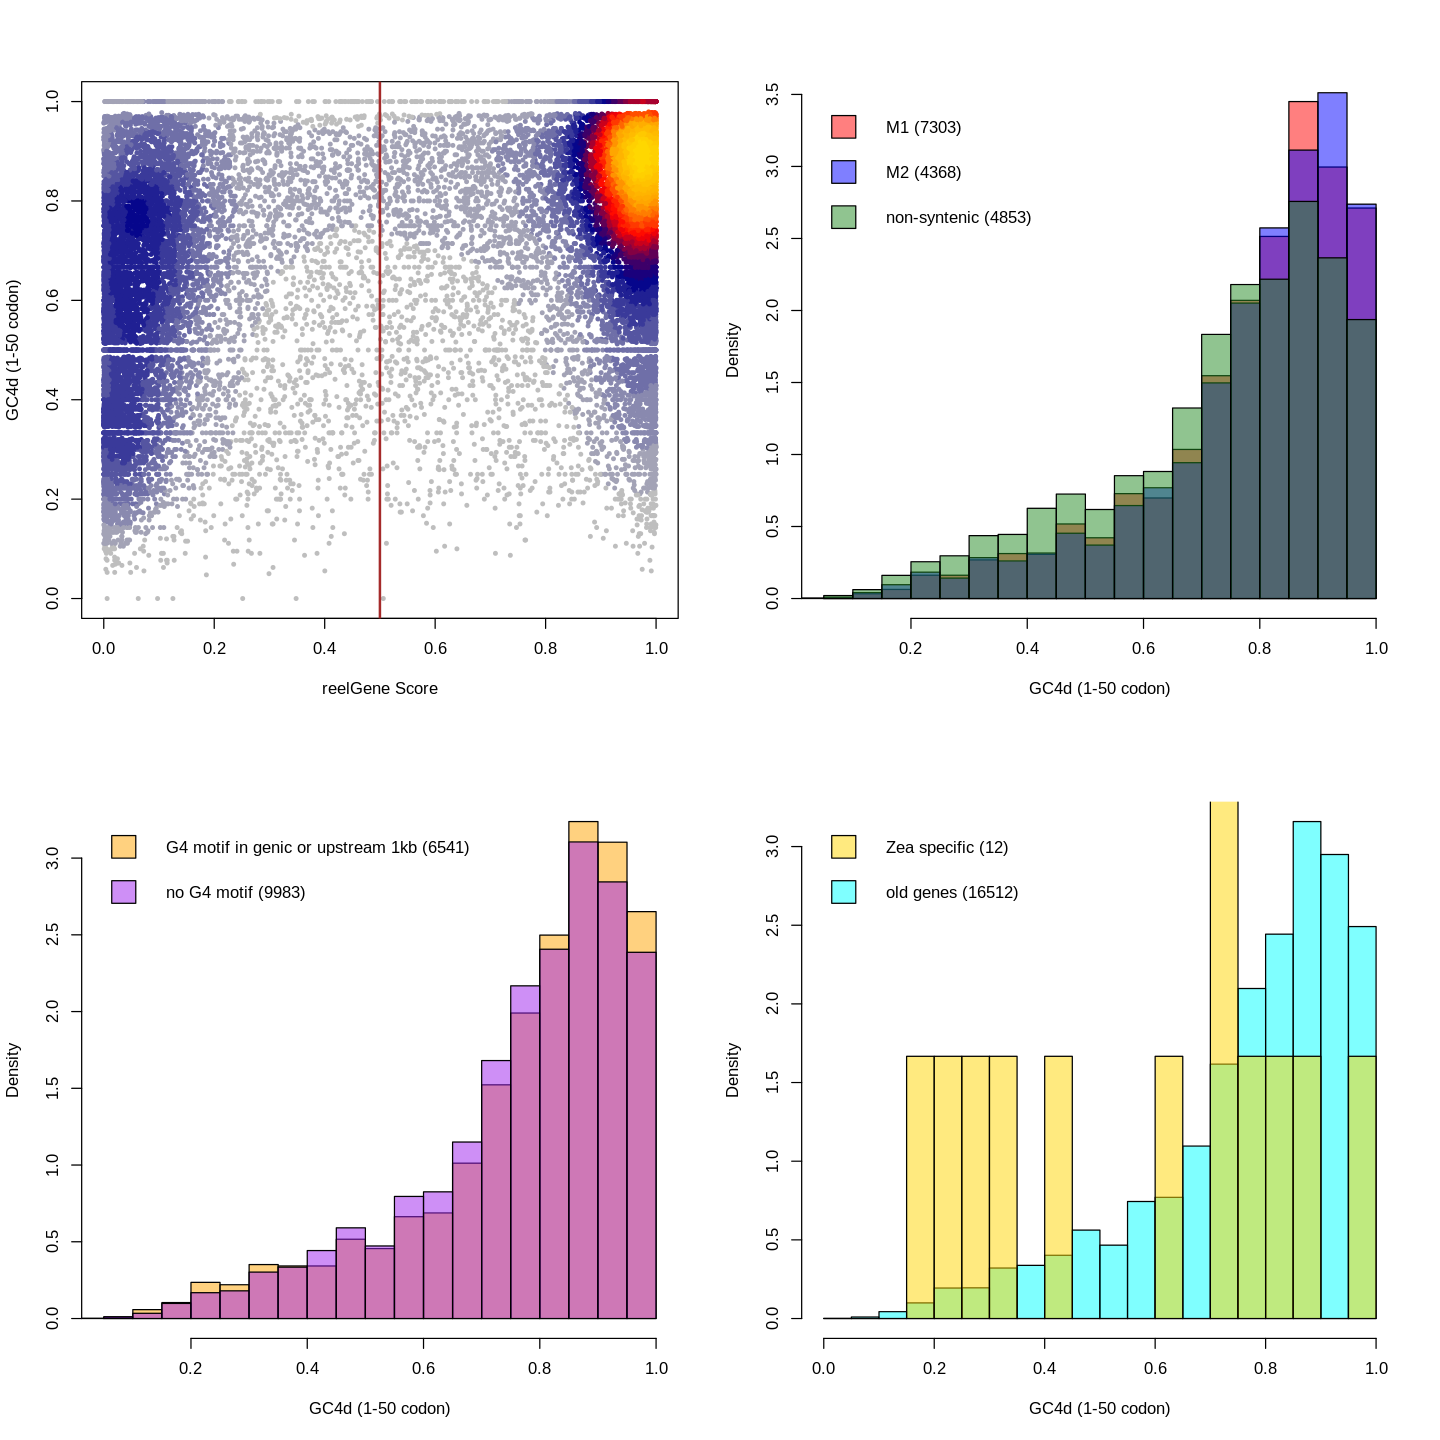

In [216]:
options(repr.plot.width=12, repr.plot.height=12)

par(mfrow = c(2,2))
with(mergedDat,LSD::heatscatter(score,gcPerGene4d50,xlab = "reelGene Score",ylab = "GC4d (1-50 codon)",main = ""))
abline(v = .5,col = "brown",lwd =2)
with(mergedDat[mergedDat$score>.5,],hist(gcPerGene4d50[Subgenome == "M1"],xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("red",.5),freq = F))
with(mergedDat[mergedDat$score>.5,],hist(gcPerGene4d50[Subgenome == "M2"],col = alpha("blue",.5),add =T,freq = F))
with(mergedDat[mergedDat$score>.5,],hist(gcPerGene4d50[Subgenome == "not-assigned"],
                                         col = alpha("forestgreen",.5),add = T, freq = F,breaks = seq(0,1,0.05)))
legend("topleft",legend = c("M1 (7303)","M2 (4368)","non-syntenic (4853)"),fill = alpha(c("red","blue","forestgreen"),.5),bty = 'n')

with(mergedDat[mergedDat$score>.5,],hist(gcPerGene4d50[G4 == 1],xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("orange",.5),freq = F))
with(mergedDat[mergedDat$score>.5,],hist(gcPerGene4d50[G4 == 0],col = alpha("purple",.5),add =T,freq = F))
legend("topleft",legend = c("G4 motif in genic or upstream 1kb (6541)","no G4 motif (9983)"),
       fill = alpha(c("orange","purple"),.5),bty = 'n')

with(mergedDat[mergedDat$score>.5,],hist(gcPerGene4d50[ZeaSpecific == 0],xlab = "GC4d (1-50 codon)",main = "",
                    col = alpha("cyan",.5),freq = F))
with(mergedDat[mergedDat$score>.5,],hist(gcPerGene4d50[ZeaSpecific == 1],col = alpha("gold",.5),add =T,freq = F,breaks = seq(0,1,0.05)))
legend("topleft",legend = c("Zea specific (12)","old genes (16512)"),
       fill = alpha(c("gold","cyan"),.5),bty = 'n')

In [272]:
testRes_envPC1_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_20250425.txt",header =T)

sigGeneEnvPC1 = na.omit(testRes_envPC1_v2$ZmID[testRes_envPC1_v2$p<.005])

hist(gcPerGene4d50[setdiff(testRes_envPC1_v2$ZmID,sigGeneEnvPC1)],breaks = seq(0,1,0.05),freq = F,
     col = alpha("grey",.5))
hist(gcPerGene4d50[sigGeneEnvPC1],breaks = seq(0,1,0.05),
     freq = F, add = T, col = alpha("red",.5))

In [340]:
dnaFasta_5utr = readDNAStringSet("/workdir/sh2246/p_phyloGWAS/output/ZmB73_5UTR.fa")
names(dnaFasta_5utr) = substr(names(dnaFasta_5utr),1,20)

In [356]:
tmp = letterFrequency(dnaFasta_5utr,letters = c("A","T","C","G"))
rownames(tmp) = names(dnaFasta_5utr)
gcPerGene_5utr = rowSums(tmp[,3:4])/rowSums(tmp)
gcCompPerGene_5utr = tmp[,3:4]/rowSums(tmp)

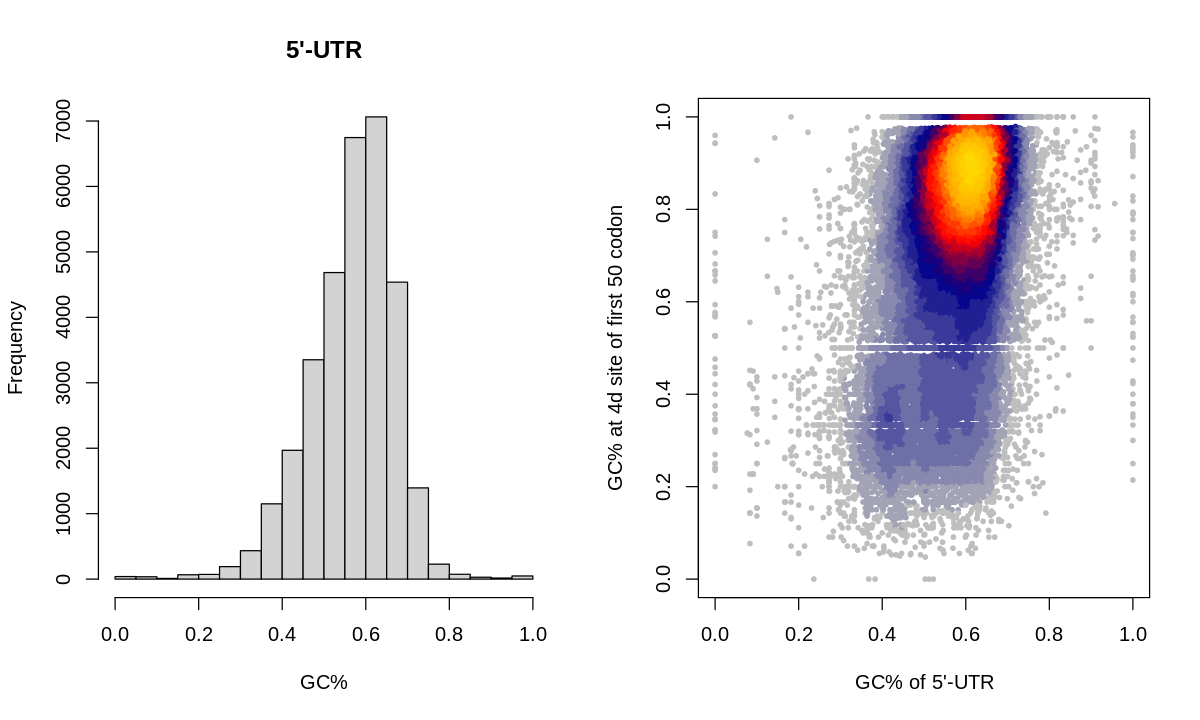

In [353]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
hist(gcPerGene_5utr[names(gcPerGene)],main = "5'-UTR",xlab = "GC%")
LSD::heatscatter(gcPerGene_5utr[names(gcPerGene)],gcPerGene4d50,main = "",
                 xlab = "GC% of 5'-UTR", ylab = "GC% at 4d site of first 50 codon")

In [350]:
cor(gcPerGene_5utr[names(gcPerGene)],gcPerGene4d50,use = "complete",method = "spearman")

[1] 0.3207577

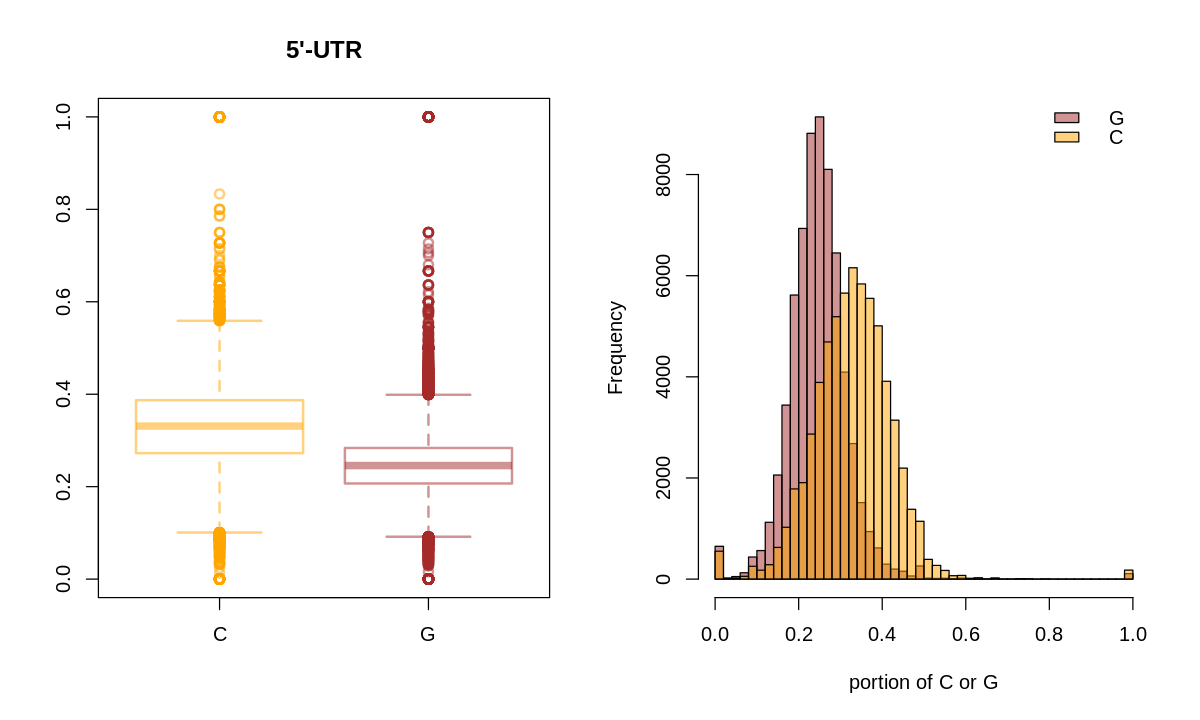

In [360]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
boxplot(gcCompPerGene_5utr, border = alpha(c("orange","brown"),.5),col = NA,lwd = 2,main = "5'-UTR")
hist(gcCompPerGene_5utr[,2],col = alpha("brown",.5),main = "",xlab = "portion of C or G",breaks = seq(0,1,0.02))
hist(gcCompPerGene_5utr[,1],add = T, col = alpha("orange",.5),breaks = seq(0,1,0.02))
legend("topright",legend = c("G", "C"), fill = alpha(c("brown","orange"),.5),bty = 'n')

In [370]:
head(gcCompPerGene_5utr)
head(gcCompPerGene50)

,C,G
Zm00001eb000010_T001,0.3428571,0.2857143
Zm00001eb000020_T002,0.2554745,0.3430657
Zm00001eb000020_T004,0.0000000,0.0000000
Zm00001eb000020_T003,0.2777778,0.2857143
Zm00001eb000020_T001,0.2497055,0.3038869
Zm00001eb000050_T001,0.3085271,0.4775194


,C,G
Zm00001eb000010_T001,0.5000000,0.1400000
Zm00001eb000050_T001,0.1933333,0.2533333
Zm00001eb000060_T001,0.2866667,0.3800000
Zm00001eb000070_T001,0.3400000,0.3200000
Zm00001eb000080_T001,0.1533333,0.2666667
Zm00001eb000100_T001,0.3133333,0.2800000


In [374]:
cor(gcCompPerGene50[commonGeneID,1],gcCompPerGene_5utr[commonGeneID,1],method = "spearman")
cor(gcCompPerGene50[commonGeneID,2],gcCompPerGene_5utr[commonGeneID,2],method = "spearman")

[1] 0.3597318

[1] 0.1535983

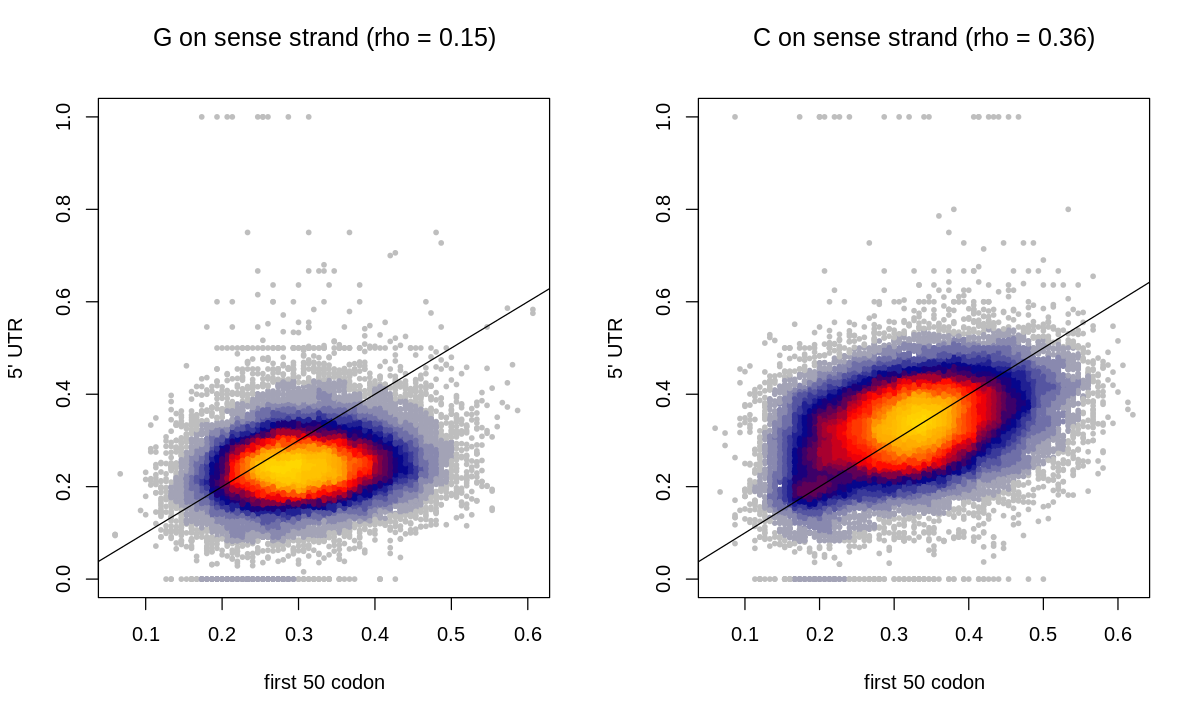

In [376]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
commonGeneID = intersect(rownames(gcCompPerGene50),rownames(gcCompPerGene_5utr))
LSD::heatscatter(gcCompPerGene50[commonGeneID,2],gcCompPerGene_5utr[commonGeneID,2],
                 main = "G on sense strand (rho = 0.15)",xlab = "first 50 codon",ylab = "5' UTR")
abline(a=0,b= 1)
LSD::heatscatter(gcCompPerGene50[commonGeneID,1],gcCompPerGene_5utr[commonGeneID,1],
                 main = "C on sense strand (rho = 0.36)",xlab = "first 50 codon",ylab = "5' UTR")
abline(a=0,b= 1)
